# 02 - Exploratory Data Analysis: Silver Layer

Explores the cleaned and standardised silver tables: 
- halo counts and host/subhalo flags,
- mass distribution by cosmology, 
- unit sanity checks, 
- protohalo coverage, 
- and match statistics. 

All data in `silver.*` tables built by `make silver`:
- silver.halos
- silver.protohalos
- silver.wdm_cdm_matches
- silver.simulation_pairs

## Setup

In [1]:
import warnings
import os
from pathlib import Path

project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

_latex = os.environ.get("LATEX_BIN_DIR")
if _latex:
    os.environ["PATH"] = _latex + ":" + os.environ["PATH"]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

from src.config import load_config
from src.db import get_connection
from src.utils.plotting import apply_style

apply_style()

cfg = load_config()

FIGURES_DIR = Path("reports/figures")

## 1. Halo counts and flags

In [2]:
conn = get_connection(cfg.database_path, read_only=True)
flag_counts = conn.execute("""
    SELECT
        simulation_id,
        COUNT(*)                          AS n_total,
        SUM(CASE WHEN is_host    THEN 1 ELSE 0 END) AS n_hosts,
        SUM(CASE WHEN is_subhalo THEN 1 ELSE 0 END) AS n_subhalos,
        SUM(CASE WHEN below_100_part_limit THEN 1 ELSE 0 END) AS n_below_100
    FROM silver.halos
    GROUP BY simulation_id
    ORDER BY simulation_id
""").pl()
conn.close()
print(flag_counts)

shape: (8, 5)
┌───────────────────┬─────────┬───────────────┬───────────────┬───────────────┐
│ simulation_id     ┆ n_total ┆ n_hosts       ┆ n_subhalos    ┆ n_below_100   │
│ ---               ┆ ---     ┆ ---           ┆ ---           ┆ ---           │
│ str               ┆ i64     ┆ decimal[38,0] ┆ decimal[38,0] ┆ decimal[38,0] │
╞═══════════════════╪═════════╪═══════════════╪═══════════════╪═══════════════╡
│ cdm_512_z39_adapt ┆ 131104  ┆ 114521        ┆ 16583         ┆ 94806         │
│ cdm_512_z39_fixed ┆ 143544  ┆ 125258        ┆ 18286         ┆ 108928        │
│ cdm_512_z99_adapt ┆ 125940  ┆ 109754        ┆ 16186         ┆ 90356         │
│ cdm_512_z99_fixed ┆ 137414  ┆ 119910        ┆ 17504         ┆ 103226        │
│ wdm_512_z39_adapt ┆ 19467   ┆ 16556         ┆ 2911          ┆ 12670         │
│ wdm_512_z39_fixed ┆ 18579   ┆ 17061         ┆ 1518          ┆ 12586         │
│ wdm_512_z99_adapt ┆ 19432   ┆ 16518         ┆ 2914          ┆ 12649         │
│ wdm_512_z99_fixed ┆ 1842

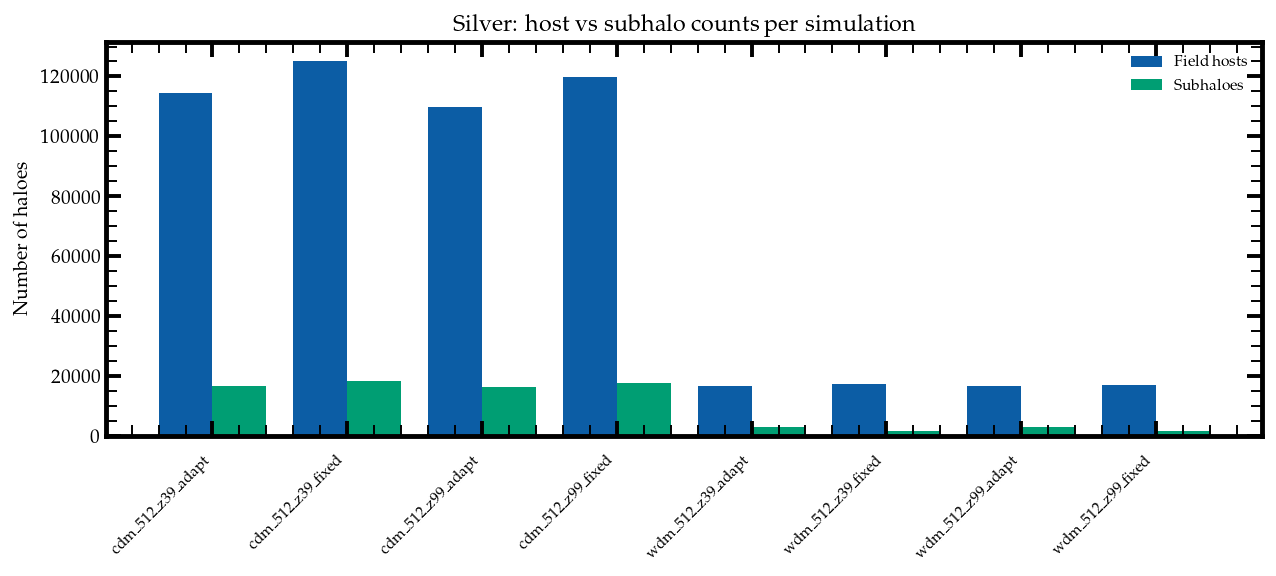

In [3]:
sim_ids  = flag_counts["simulation_id"].to_list()
n_hosts  = flag_counts["n_hosts"].to_numpy()
n_subs   = flag_counts["n_subhalos"].to_numpy()
x        = np.arange(len(sim_ids))
width    = 0.4

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
_ = ax.bar(x - width / 2, n_hosts, width=width, color="#0C5DA5", label="Field hosts")
_ = ax.bar(x + width / 2, n_subs,  width=width, color="#009E73", label="Subhaloes")
_ = ax.set_xticks(x)
_ = ax.set_xticklabels(sim_ids, rotation=45, ha="right", fontsize=8)
_ = ax.set_ylabel("Number of haloes")
_ = ax.set_title("Silver: host vs subhalo counts per simulation")
_ = ax.legend()

## 2. Mass distribution

Halo mass $M_{200}$ in $h^{-1}\,{\rm M}_\odot$ on a $\log_{10}$ scale, split by cosmology. 

As WDM suppresses low-mass structure, the sharp WDM cutoff around $\log_{10}(M_{200}) \approx 8$–9 is the approximately free-streaming scale. However, artificial fragmentation induces spurious haloes, which show as an upturn in the halo counts below the free-streaming scale.

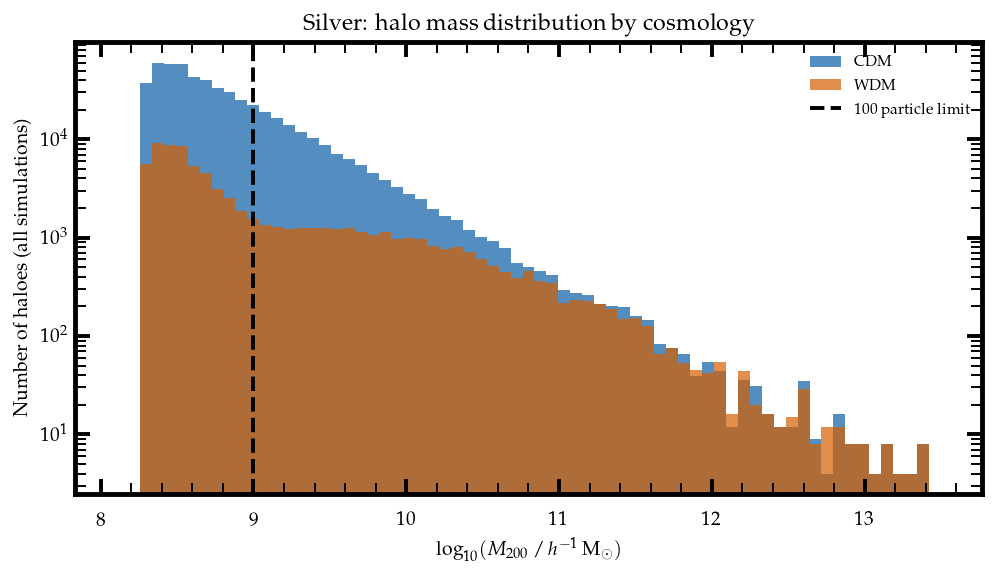

In [11]:
conn = get_connection(cfg.database_path, read_only=True)
masses = conn.execute("""
    SELECT
        LOG10(m_halo_msun_h) AS log10_m,
        cosmology
    FROM silver.halos
    WHERE m_halo_msun_h > 0
""").pl()
conn.close()

log_m_cdm = masses.filter(pl.col("cosmology") == "CDM")["log10_m"].to_numpy()
log_m_wdm = masses.filter(pl.col("cosmology") == "WDM")["log10_m"].to_numpy()

bins = np.linspace(8.1, 13.5, 70)
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
_ = ax.hist(log_m_cdm, bins=bins, color="#0C5DA5", alpha=0.7, label="CDM")
_ = ax.hist(log_m_wdm, bins=bins, color="#D55E00", alpha=0.7, label="WDM")
_ = ax.axvline(9, color="k", linestyle="--", label=r"100 particle limit")
_ = ax.set_xlabel(r"$\log_{10}(M_{200}\,/\,h^{-1}\,{\rm M}_\odot)$")
_ = ax.set_ylabel("Number of haloes (all simulations)")
_ = ax.set_yscale("log")
_ = ax.set_title("Silver: halo mass distribution by cosmology")
_ = ax.legend()
fig.savefig(FIGURES_DIR / "02_silver_mass_distribution.png", dpi=200, bbox_inches="tight")

## 3. Unit sanity checks

Position coordinates should lie within $[0,\;25\,000]$ $h^{-1}\,{\rm kpc}$ (the 25 $h^{-1}\,{\rm Mpc}$ box).
 
Mass should exceed the single-particle mass of $10^7\,h^{-1}\,{\rm M}_\odot$ for all haloes above the 100-particle limit.

In [5]:
conn = get_connection(cfg.database_path, read_only=True)
sanity = conn.execute("""
    SELECT
        simulation_id,
        MIN(x_kpc_h)       AS x_min,
        MAX(x_kpc_h)       AS x_max,
        MIN(y_kpc_h)       AS y_min,
        MAX(y_kpc_h)       AS y_max,
        MIN(z_kpc_h)       AS z_min,
        MAX(z_kpc_h)       AS z_max,
        MIN(m_halo_msun_h) AS mass_min,
        MAX(m_halo_msun_h) AS mass_max
    FROM silver.halos
    GROUP BY simulation_id
    ORDER BY simulation_id
""").pl()
conn.close()

# Positions expected in [0, 25 000]; mass_min expected >= 1e7 for 100-part limit.
print(sanity)

shape: (8, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ simulatio ┆ x_min     ┆ x_max     ┆ y_min     ┆ … ┆ z_min    ┆ z_max     ┆ mass_min  ┆ mass_max  │
│ n_id      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---      ┆ ---       ┆ ---       ┆ ---       │
│ ---       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64      ┆ f64       ┆ f64       ┆ f64       │
│ str       ┆           ┆           ┆           ┆   ┆          ┆           ┆           ┆           │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ cdm_512_z ┆ 0.033775  ┆ 24999.687 ┆ 9.155273  ┆ … ┆ 0.209621 ┆ 24999.827 ┆ 2.00242e8 ┆ 5.4601e13 │
│ 39_adapt  ┆           ┆ 958       ┆           ┆   ┆          ┆ 162       ┆           ┆           │
│ cdm_512_z ┆ 0.956438  ┆ 24999.788 ┆ 3.492987  ┆ … ┆ 0.289691 ┆ 24999.764 ┆ 2.00242e8 ┆ 5.4736e13 │
│ 39_fixed  ┆           ┆ 256       ┆           ┆   ┆          ┆ 995       ┆ 

## 4. Protohalo coverage

In [6]:
conn = get_connection(cfg.database_path, read_only=True)
coverage = conn.execute("""
    SELECT
        simulation_id,
        COUNT(*)  AS n_total,
        SUM(CASE WHEN has_protohalo_data THEN 1 ELSE 0 END)     AS n_with_proto,
        SUM(CASE WHEN NOT has_protohalo_data THEN 1 ELSE 0 END) AS n_without_proto
    FROM silver.protohalos
    GROUP BY simulation_id
    ORDER BY simulation_id
""").pl()
conn.close()

coverage = coverage.with_columns(
    (pl.col("n_with_proto").cast(pl.Float64) / pl.col("n_total")).alias("frac_covered")
)
print(coverage)

shape: (8, 5)
┌───────────────────┬─────────┬───────────────┬─────────────────┬──────────────┐
│ simulation_id     ┆ n_total ┆ n_with_proto  ┆ n_without_proto ┆ frac_covered │
│ ---               ┆ ---     ┆ ---           ┆ ---             ┆ ---          │
│ str               ┆ i64     ┆ decimal[38,0] ┆ decimal[38,0]   ┆ f64          │
╞═══════════════════╪═════════╪═══════════════╪═════════════════╪══════════════╡
│ cdm_512_z39_adapt ┆ 131104  ┆ 101743        ┆ 29361           ┆ 0.776048     │
│ cdm_512_z39_fixed ┆ 143544  ┆ 107890        ┆ 35654           ┆ 0.751616     │
│ cdm_512_z99_adapt ┆ 125940  ┆ 97703         ┆ 28237           ┆ 0.77579      │
│ cdm_512_z99_fixed ┆ 137414  ┆ 103282        ┆ 34132           ┆ 0.751612     │
│ wdm_512_z39_adapt ┆ 19467   ┆ 13060         ┆ 6407            ┆ 0.670879     │
│ wdm_512_z39_fixed ┆ 18579   ┆ 10452         ┆ 8127            ┆ 0.562571     │
│ wdm_512_z99_adapt ┆ 19432   ┆ 13023         ┆ 6409            ┆ 0.670183     │
│ wdm_512_z99_

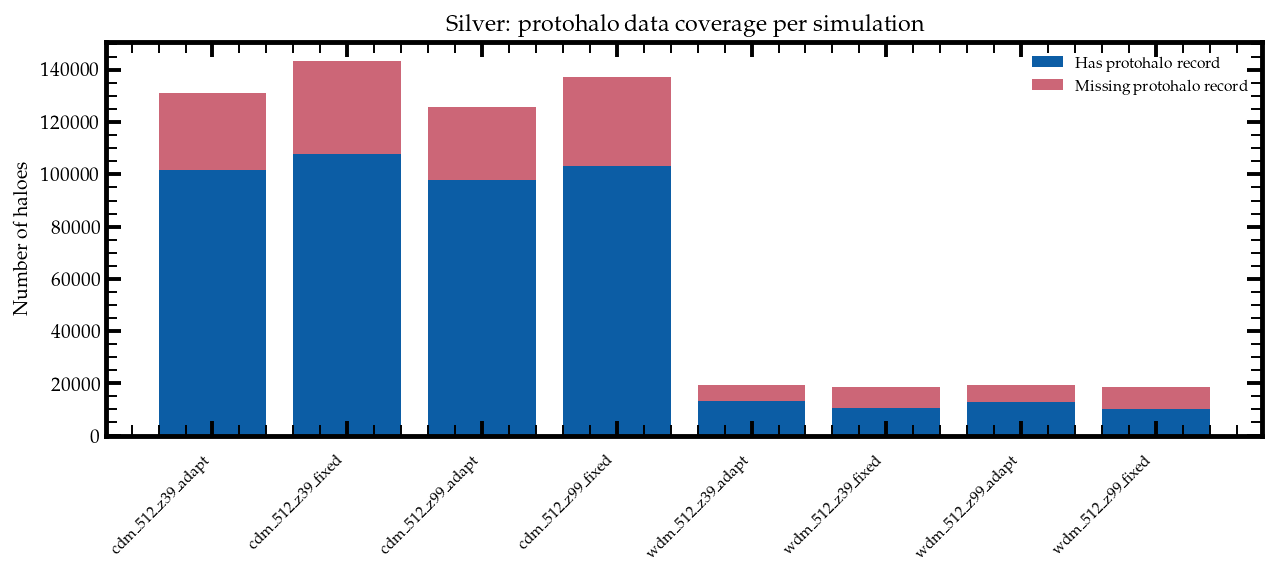

In [7]:
sim_ids  = coverage["simulation_id"].to_list()
n_with   = coverage["n_with_proto"].to_numpy()
n_wo     = coverage["n_without_proto"].to_numpy()
x        = np.arange(len(sim_ids))

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
_ = ax.bar(x, n_with, color="#0C5DA5", label="Has protohalo record")
_ = ax.bar(x, n_wo,   bottom=n_with, color="#CC6677", label="Missing protohalo record")
_ = ax.set_xticks(x)
_ = ax.set_xticklabels(sim_ids, rotation=45, ha="right", fontsize=8)
_ = ax.set_ylabel("Number of haloes")
_ = ax.set_title("Silver: protohalo data coverage per simulation")
_ = ax.legend()
fig.savefig(FIGURES_DIR / "02_silver_protohalo_coverage.png", dpi=200, bbox_inches="tight")

### Sphericity distribution

For haloes with protohalo records we note that CDM haloes tend toward higher sphericity ($s \to 1$) than WDM haloes. 

Nevertheless, the sphericity overlap in CDM and WDM haloes is substantial. This is why a single threshold (equation 4 of the paper) is a blunt diagnostic. 

Note that we need to normalise by the total number of haloes in each distribution in order to have a fair comparison.

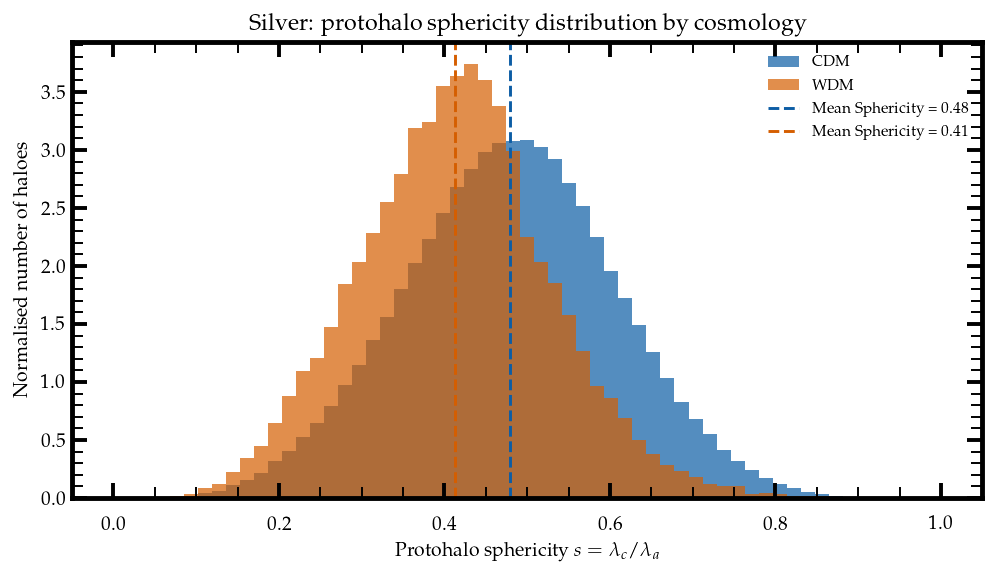

In [8]:
conn = get_connection(cfg.database_path, read_only=True)
sphericity = conn.execute("""
    SELECT
        p.sphericity_s,
        s.cosmology
    FROM silver.protohalos p
    JOIN silver.halos s
        ON p.halo_id = s.halo_id AND p.simulation_id = s.simulation_id
    WHERE p.has_protohalo_data
""").pl()
conn.close()

s_cdm = sphericity.filter(pl.col("cosmology") == "CDM")["sphericity_s"].to_numpy()
s_wdm = sphericity.filter(pl.col("cosmology") == "WDM")["sphericity_s"].to_numpy()

s_cdm_mean = np.mean(s_cdm)
s_wdm_mean = np.mean(s_wdm)

bins = np.linspace(0, 1, 60)
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
_ = ax.hist(s_cdm, bins=bins, density=True, color="#0C5DA5", alpha=0.7, label="CDM")
_ = ax.hist(s_wdm, bins=bins, density=True, color="#D55E00", alpha=0.7, label="WDM")
_ = ax.axvline(s_cdm_mean, color="#0C5DA5", linestyle="--", linewidth=1.5, label=f"Mean Sphericity = {s_cdm_mean:.2f}")
_ = ax.axvline(s_wdm_mean, color="#D55E00", linestyle="--", linewidth=1.5, label=f"Mean Sphericity = {s_wdm_mean:.2f}")
_ = ax.set_xlabel(r"Protohalo sphericity $s = \lambda_c / \lambda_a$")
_ = ax.set_ylabel("Normalised number of haloes")
_ = ax.set_title("Silver: protohalo sphericity distribution by cosmology")
_ = ax.legend()

## 5. Match statistics

In [9]:
conn = get_connection(cfg.database_path, read_only=True)
match_stats = conn.execute("""
    SELECT
        simulation_pair_id,
        COUNT(*)  AS n_wdm_halos,
        SUM(CASE WHEN has_cdm_counterpart THEN 1 ELSE 0 END)     AS n_genuine,
        SUM(CASE WHEN NOT has_cdm_counterpart THEN 1 ELSE 0 END) AS n_spurious
    FROM silver.wdm_cdm_matches
    GROUP BY simulation_pair_id
    ORDER BY simulation_pair_id
""").pl()
conn.close()

match_stats = match_stats.with_columns(
    (pl.col("n_spurious").cast(pl.Float64) / pl.col("n_wdm_halos")).alias("frac_spurious")
)
print(match_stats)

shape: (4, 5)
┌────────────────────┬─────────────┬───────────────┬───────────────┬───────────────┐
│ simulation_pair_id ┆ n_wdm_halos ┆ n_genuine     ┆ n_spurious    ┆ frac_spurious │
│ ---                ┆ ---         ┆ ---           ┆ ---           ┆ ---           │
│ str                ┆ i64         ┆ decimal[38,0] ┆ decimal[38,0] ┆ f64           │
╞════════════════════╪═════════════╪═══════════════╪═══════════════╪═══════════════╡
│ z39_adapt          ┆ 3972        ┆ 3631          ┆ 341           ┆ 0.085851      │
│ z39_fixed          ┆ 3506        ┆ 3245          ┆ 261           ┆ 0.074444      │
│ z99_adapt          ┆ 3947        ┆ 3585          ┆ 362           ┆ 0.091715      │
│ z99_fixed          ┆ 3510        ┆ 3234          ┆ 276           ┆ 0.078632      │
└────────────────────┴─────────────┴───────────────┴───────────────┴───────────────┘
